# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
# TODO
print("so dong:", df.shape[0], "so cot:", df.shape[1])
print()
print(df.info())

so dong: 1338 so cot: 7

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


## A.2. Missing values & Duplicate data

In [8]:
# TODO
missing = df.isnull().sum()
print("Missing values:\n", missing)
print("\nDuplicate data:", df.duplicated().sum())

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate data: 1


## A.3. Invalid values

In [ ]:
# TODO
print("Kiem tra gia tri invalid")
print((df[['age', 'bmi', 'children', 'charges']] < 0).sum())
print("\nUnique values ở các cột phân loại:")
for col in ['sex', 'smoker', 'region']:
    print(f"{col}: {df[col].unique()}")

Kiểm tra giá trị âm hoặc bất thường:
age         0
bmi         0
children    0
charges     0
dtype: int64

Unique values ở các cột phân loại:
sex: <StringArray>
['female', 'male']
Length: 2, dtype: str
smoker: <StringArray>
['yes', 'no']
Length: 2, dtype: str
region: <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [17]:
conditions = [df['bmi'] < 25, df['bmi'] < 30]
choices = ['Normal', 'Overweight']

df['bmi_group'] = np.select(conditions, choices, default='Obese')
df

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Obese
1334,18,female,31.920,0,no,northeast,2205.98080,Obese
1335,18,female,36.850,0,no,southeast,1629.83350,Obese
1336,21,female,25.800,0,no,southwest,2007.94500,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [ ]:
# # TODO
cols = ['age', 'bmi', 'children', 'charges']
for col in cols:
    _mean = df[col].mean()
    _median = df[col].median()
    _mode = df[col].mode()[0]
    print(f"[{col}] Mean: {_mean: .2f} | Median: {_median: .2f} | Mode: {_mode: .2f}")

[age] Mean:  39.21 | Median:  39.00 | Mode:  18.00
[bmi] Mean:  30.66 | Median:  30.40 | Mode:  32.30
[children] Mean:  1.09 | Median:  1.00 | Mode:  0.00
[charges] Mean:  13270.42 | Median:  9382.03 | Mode:  1639.56


## Group 2 — Dispersion

In [7]:
# TODO

disp = {}
cols = ['age', 'bmi', 'children', 'charges']
for col in cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    disp[col] = {
        'Variance': s.var(),
        'Std Dev': s.std(),
        'Range': s.max() - s.min(),
        'IQR': q3 -q1,
        'CV (%)': (s.std() / s.mean()) * 100
    }
pd.DataFrame(disp)

,age,bmi,children,charges
Variance,197.401387,37.187884,1.453213,1.466524e+08
Std Dev,14.049960,6.098187,1.205493,1.211001e+04
Range,46.000000,37.170000,5.000000,6.264855e+04
IQR,24.000000,8.397500,2.000000,1.189963e+04
CV (%),35.835313,19.887513,110.098927,9.125566e+01


## Group 3 — Location and Shape

In [8]:
# TODO
cols = ['age', 'bmi', 'children', 'charges']
percentiles = df[cols].quantile([0.25, 0.50, 0.75])
skewness = df[cols].skew().to_frame(name='skewness').T
kurt = df[cols].kurtosis().to_frame(name='kurtosis').T
pd.concat([percentiles, skewness, kurt])

,age,bmi,children,charges
0.25,27.000000,26.296250,0.000000,4740.287150
0.5,39.000000,30.400000,1.000000,9382.033000
0.75,51.000000,34.693750,2.000000,16639.912515
skewness,0.055673,0.284047,0.938380,1.515880
kurtosis,-1.245088,-0.050732,0.202454,1.606299


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

smoker              no           yes  Gap_bao_nhieu_lan
region                                                 
northeast  9165.531672  29673.536473           3.237514
northwest  8556.463715  30192.003182           3.528561
southeast  8032.216309  34844.996824           4.338155
southwest  8019.284513  32269.063494           4.023933


C:\Users\HP\AppData\Local\Temp\ipykernel_6676\2244818907.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x = 'region', y = 'charges', hue='smoker', ci=None)


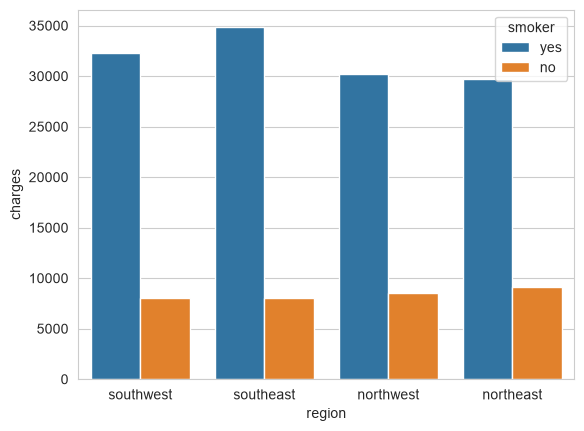

In [12]:
# TODO
kq = df.groupby(['region', 'smoker'])['charges'].mean().unstack()
kq['Gap_bao_nhieu_lan'] = kq['yes'] / kq['no']
print(kq)

sns.barplot(data=df, x = 'region', y = 'charges', hue='smoker', ci=None)
plt.show()

In [9]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

He so tuong quan nhom hut thuoc:  0.806
He so tuong quan nhom khong hut thuoc:  0.084


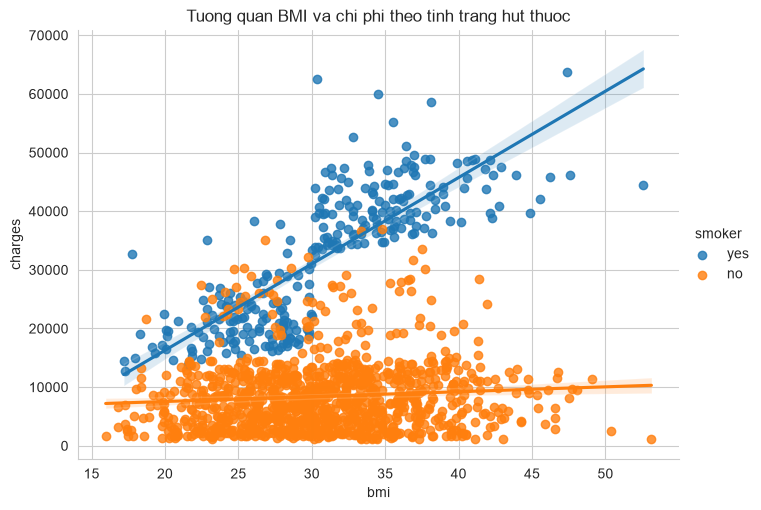

In [13]:
corr_hut_thuoc = df[df['smoker'] == 'yes']['bmi'].corr(df[df['smoker'] == 'yes']['charges'])
corr_khong_hut = df[df['smoker'] == 'no']['bmi'].corr(df[df['smoker'] == 'no']['charges'])

print(f'He so tuong quan nhom hut thuoc: {corr_hut_thuoc: .3f}')
print(f'He so tuong quan nhom khong hut thuoc: {corr_khong_hut: .3f}')

sns.lmplot(data=df, x='bmi', y='charges', hue='smoker', aspect=1.4)
plt.title('Tuong quan BMI va chi phi theo tinh trang hut thuoc')
plt.show()

## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

region
southeast    14735.41
northeast    13406.38
northwest    12417.58
southwest    12346.94
Name: charges, dtype: float64


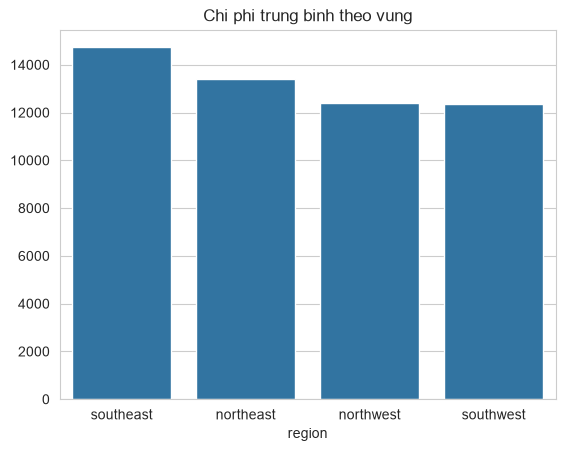

In [15]:
# TODO
region_charges = df.groupby('region')['charges'].mean().sort_values(ascending=False)
print(region_charges.round(2))

sns.barplot(x=region_charges.index, y=region_charges.values)
plt.title('Chi phi trung binh theo vung')
plt.show()


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

          count          mean       median
children                                  
0           574  12365.975602   9856.95190
1           324  12731.171832   8483.87015
2           240  15073.563734   9264.97915
3           157  15355.318367  10600.54830
4            25  13850.656311  11033.66170
5            18   8786.035247   8589.56505


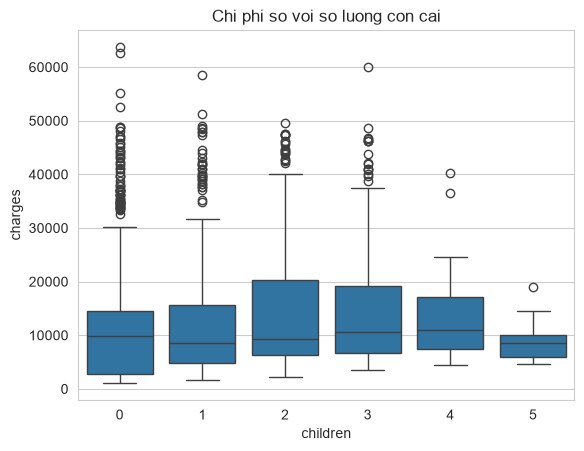

In [20]:
# TODO
print(df.groupby('children')['charges'].agg(['count', 'mean', 'median']))
sns.boxplot(data=df, x='children', y = 'charges')
plt.title("Chi phi so voi so luong con cai")
plt.show()

In [16]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

Hệ số tương quan giữa Age và Charges: 0.299


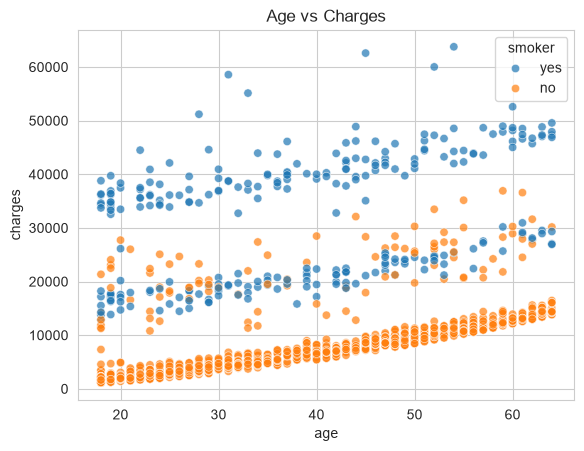

In [21]:
# TODO
corr_age = df['age'].corr(df['charges'])
print(f"Hệ số tương quan giữa Age và Charges: {corr_age:.3f}")

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7)
plt.title('Age vs Charges')
plt.show()

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

1. Hút thuốc là yếu tố lớn nhất làm cho chi phí bảo hiểm tăng cao
2. BMI tác động xấu đến chi phi ở nhóm hút thuốc, đối với nhóm không hút thuốc thì không bị tác động rõ rệt
3. Vùng Southeast có mức chi phí bảo hiểm trung bình cao nhất trong khu vực do có tỷ lệ hút thuốc và BMI cao so với các vùng khác
4. Chi phí bảo hiểm tăng tỷ lệ thuận với độ tuổi, do thói quen hút thuốc